# Lecture 10

## Example gapminder data

* data from https://www.gapminder.org/data
* talk by Hans Rosling at https://www.ted.com/talks/hans_rosling_new_insights_on_poverty
* we aim to reconstruct a figure in the talk from public data with matplotlib

In [1]:
%ls *.csv

child_mortality_0_5_year_olds_dying_per_1000_born.csv  lex.csv
gdp_pcap.csv                                           pop.csv


In [2]:
import pandas as pd

In [4]:
gdp = pd.read_csv('gdp_pcap.csv').set_index('name')
gdp.head()

,geo,1800,1801,1802,1803,1804,1805,1806,1807,1808,...,2091,2092,2093,2094,2095,2096,2097,2098,2099,2100
name,,,,,,,,,,,,,,,,,,,,,
Afghanistan,afg,560.88817,560.88817,560.88817,560.88817,560.88817,560.88817,560.88817,560.88817,560.88817,...,9397.79550,9628.20479,9864.18612,10105.83025,10353.22669,10606.46351,10865.62717,11130.80231,11402.07162,11679.51560
Angola,ago,435.23259,436.64111,438.75389,440.86667,442.27519,444.38797,446.50074,448.61352,450.72630,...,30471.68022,30991.50308,31513.98698,32038.95027,32566.20896,33095.57701,33626.86659,34159.88835,34694.45172,35230.36514
Albania,alb,547.53369,549.10393,550.67868,552.25795,553.84175,555.43009,557.02298,558.62044,560.22248,...,57444.50359,57884.32605,58319.28840,58749.34444,59174.45223,59594.57402,60009.67615,60419.72899,60824.70684,61224.58783
Andorra,and,1598.53128,1601.20217,1603.87307,1607.87941,1610.55031,1613.22120,1615.89210,1618.56300,1622.56934,...,82535.68235,82627.86812,82718.08635,82806.37556,82892.77367,82977.31800,83060.04528,83140.99165,83220.19266,83297.68327
UAE,are,1332.77712,1336.78346,1342.12526,1347.46705,1352.80884,1356.81518,1362.15698,1367.49877,1372.84056,...,81900.09821,81885.61721,81871.47395,81857.66048,81844.16902,81830.99199,81818.12198,81805.55176,81793.27428,81781.28265


In [6]:
childm = pd.read_csv('child_mortality_0_5_year_olds_dying_per_1000_born.csv').set_index('name')
childm.head()

,geo,1800,1801,1802,1803,1804,1805,1806,1807,1808,...,2091,2092,2093,2094,2095,2096,2097,2098,2099,2100
name,,,,,,,,,,,,,,,,,,,,,
Afghanistan,afg,468.58,468.58,468.58,468.58,468.58,468.58,469.98,469.98,469.98,...,10.59,10.41,10.23,10.05,9.88,9.70,9.52,9.36,9.17,9.17
Angola,ago,485.68,485.68,485.68,485.68,485.68,485.68,485.68,485.68,485.68,...,23.12,22.82,22.52,22.17,21.84,21.55,21.31,21.06,20.83,20.83
Albania,alb,375.20,375.20,375.20,375.20,375.20,375.20,375.20,375.20,375.20,...,1.78,1.76,1.74,1.71,1.69,1.67,1.65,1.63,1.60,1.60
Andorra,and,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.43,0.41,0.41,0.40,0.39,0.38,0.37,0.36,0.35,0.35
UAE,are,434.46,434.46,434.46,434.46,434.46,434.46,434.46,434.46,434.46,...,1.10,1.08,1.06,1.05,1.03,1.01,0.99,0.98,0.96,0.96


* We select a given year and fill a new dataframe with data for x and y axes: GDP and Child mortality

In [8]:
df = pd.DataFrame()
df['gdp'] = gdp['1921']
df['childm'] = childm['1921']
df.head()

,gdp,childm
name,,
Afghanistan,1059.23420,464.60
Angola,904.97391,464.60
Albania,956.82701,358.91
Andorra,5686.33765,NaN
UAE,2943.32743,415.60


* Our starting point is a scatter plot with this data

<Axes: xlabel='gdp', ylabel='childm'>

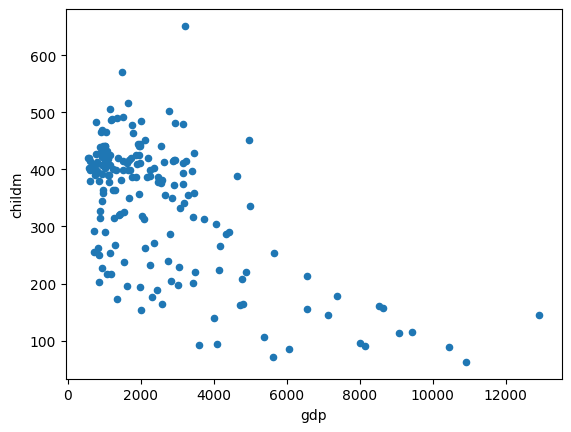

In [10]:
df.plot.scatter(x = 'gdp', y='childm')

* We see that calling the dataframe plot methods is in principle the same as calling the matplotlib routines directly

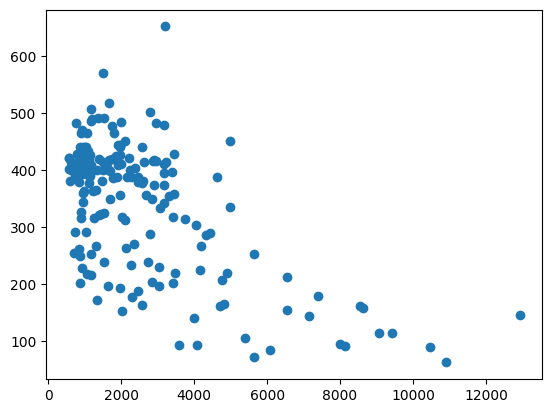

In [14]:
# compare calling matplot directly
import matplotlib.pyplot as plt
import numpy as np
plt.scatter(df['gdp'], df['childm'])

* The original has logarithmic axes

<Axes: xlabel='gdp', ylabel='childm'>

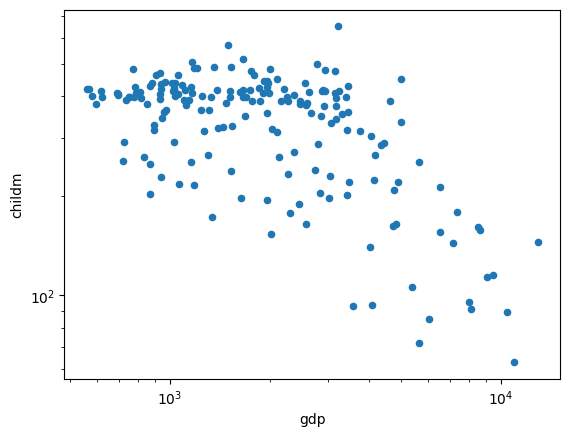

In [16]:
df.plot.scatter(x = 'gdp', y='childm', logx=True, logy=True)

* Read in population data that will represent the size of the dots in the scatter plot

In [18]:
# read in the population
pop = pd.read_csv('pop.csv').set_index('name')
pop.head()

,geo,1800,1801,1802,1803,1804,1805,1806,1807,1808,...,2091,2092,2093,2094,2095,2096,2097,2098,2099,2100
name,,,,,,,,,,,,,,,,,,,,,
Afghanistan,afg,3280000,3280000,3280000,3280000,3280000,3280000,3280000,3280000,3280000,...,124110001.0,124854162.0,125589411.0,126306889.0,126990147.0,127647762.0,128305496.0,128964762.0,129616118.0,130216739.0
Angola,ago,1567028,1567028,1567028,1567028,1567028,1567028,1567028,1567028,1567028,...,138919849.0,140249378.0,141550054.0,142835147.0,144102524.0,145340832.0,146549586.0,147743369.0,148912810.0,150045574.0
Albania,alb,400000,401773,403554,405343,407140,408945,410758,412579,414408,...,1344055.0,1324192.0,1304876.0,1286145.0,1268008.0,1250429.0,1233362.0,1216785.0,1200681.0,1184997.0
Andorra,and,2654,2654,2654,2654,2654,2654,2654,2654,2654,...,52781.0,52134.0,51484.0,50843.0,50211.0,49586.0,48973.0,48373.0,47791.0,47222.0
UAE,are,40153,40153,40153,40153,40153,40153,40153,40153,40153,...,24075187.0,24298127.0,24521988.0,24747048.0,24973506.0,25201603.0,25431504.0,25663508.0,25897696.0,26134299.0


* We scale the population arbitrarily to improve visiblility. Sqruare root means that the area will be a measure of population size

In [27]:
df['pop'] = np.sqrt(pop['1921']) / 10 # make circle area proportional to population
df.head()

,gdp,childm,pop
name,,,
Afghanistan,1059.23420,464.60,325.030829
Angola,904.97391,464.60,170.492551
Albania,956.82701,358.91,97.109577
Andorra,5686.33765,NaN,7.489326
UAE,2943.32743,415.60,23.938463


<Axes: xlabel='gdp', ylabel='childm'>

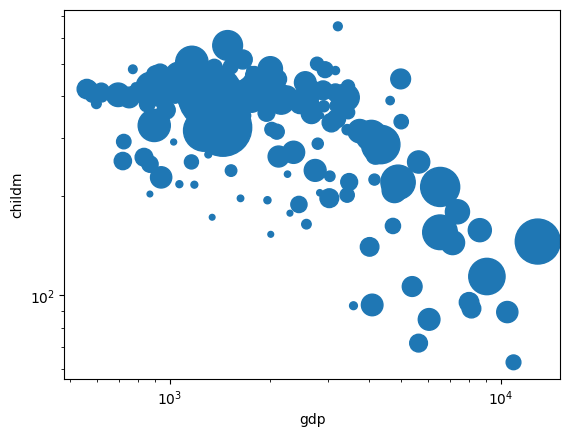

In [28]:
df.plot.scatter(x = 'gdp', y='childm', s='pop', logx=True, logy=True)

* Matplotlib plots has an argument called alpha for transparency of the dots

<Axes: xlabel='gdp', ylabel='childm'>

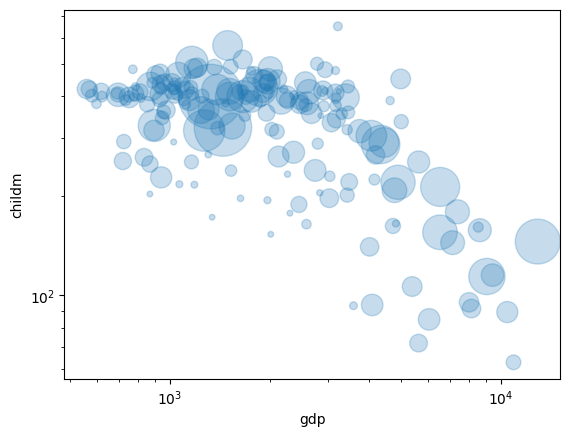

In [32]:
# alpha for transparency

df.plot.scatter(x = 'gdp', y='childm', s='pop', logx=True, logy=True, alpha=.25)

We select out single countries for plotting with alternative color. 



In [43]:
countries = ['Sweden', 'USA']
df.loc[countries]

,gdp,childm,pop
name,,,
Sweden,6066.94033,84.64,243.127970
USA,12920.45955,145.53,1046.979078


We also invert the y-axis so that it comes a measure of increasing health (lower child mortality) vs increasing wealth (gdp) on the x-axis

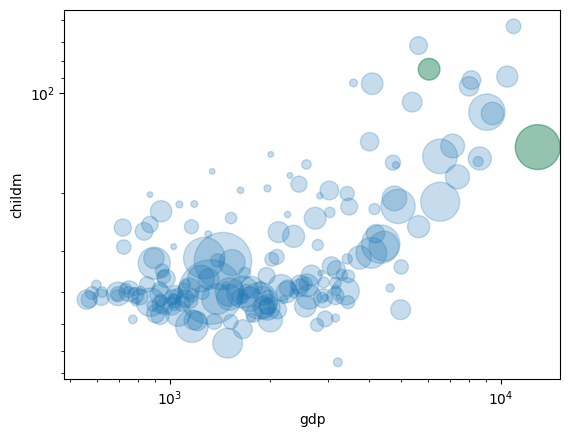

In [42]:
# Select Sweden

fig, ax = plt.subplots()

df.plot.scatter(x = 'gdp', y='childm', s='pop', logx=True, logy=True, alpha=.25, ax=ax)

df.loc[countries].plot.scatter(x = 'gdp', y='childm', s='pop', c='green', logx=True, logy=True, alpha=.25, ax=ax)
ax.invert_yaxis()